<a href="https://colab.research.google.com/github/malick08012/Book-Data-Scraper-from-OpenLibrary/blob/main/Book_Data_Scraper_from_OpenLibrary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


IMPORT LIBRARIES

In [3]:
!pip install requests pandas


Fetch Data from OpenLibrary

In [4]:
import requests

# Define the URL
url = "https://openlibrary.org/subjects/love.json?limit=10"

# Make the request
response = requests.get(url)

# Check if successful
if response.status_code == 200:
    data = response.json()
    print("✅ Data fetched successfully!")
    print("Top-level keys in JSON:", data.keys())  # Preview structure
else:
    print("❌ Failed to fetch data:", response.status_code)


✅ Data fetched successfully!
Top-level keys in JSON: dict_keys(['key', 'name', 'subject_type', 'work_count', 'works'])


Extract and Store Book Info

In [5]:
import pandas as pd

# Extract books from 'works'
books = data['works']

# Create a list to store cleaned book info
book_list = []

# Loop through and extract required fields
for book in books:
    title = book.get('title', 'N/A')
    authors = ', '.join([author['name'] for author in book.get('authors', [])])
    publish_year = book.get('first_publish_year', 'N/A')

    # Add to list
    book_list.append({
        'Title': title,
        'Authors': authors,
        'First Publish Year': publish_year
    })

# Convert to DataFrame
df = pd.DataFrame(book_list)

# Display the result
df


,Title,Authors,First Publish Year
0,Wuthering Heights,Emily Brontë,1846
1,The Great Gatsby,F. Scott Fitzgerald,1920
2,Ethan Frome,Edith Wharton,1910
3,Romeo and Juliet,William Shakespeare,1597
4,Anna Karenina,Лев Толстой,1876
5,πολιτεία,Πλάτων,1554
6,Le Comte de Monte Cristo,Alexandre Dumas,1830
7,Sonnets,William Shakespeare,1609
8,As You Like It,William Shakespeare,1734
9,The Importance of Being Earnest,Oscar Wilde,1893


 Save to CSV

In [6]:
# Save to CSV file
df.to_csv("openlibrary_books.csv", index=False)

print("📁 File saved as openlibrary_books.csv")


📁 File saved as openlibrary_books.csv


Data Cleaning & Preprocessing

In [8]:
import pandas as pd

# Load the dataset
df = pd.read_csv("openlibrary_books.csv")

# Show first few rows
df.head()


,Title,Authors,First Publish Year
0,Wuthering Heights,Emily Brontë,1846
1,The Great Gatsby,F. Scott Fitzgerald,1920
2,Ethan Frome,Edith Wharton,1910
3,Romeo and Juliet,William Shakespeare,1597
4,Anna Karenina,Лев Толстой,1876


Check for missing values

In [9]:
# Show count of missing values in each column
df.isnull().sum()


,0
Title,0
Authors,0
First Publish Year,0


Convert Categorical Data to Numeric (if needed)

In [10]:
df.dtypes


,0
Title,object
Authors,object
First Publish Year,int64


Feature Engineering

In [11]:
# Add length of title
df['Title Length'] = df['Title'].apply(len)

# Add number of authors (in case of multiple authors separated by comma)
df['Num Authors'] = df['Authors'].apply(lambda x: len(x.split(',')))

# Show updated DataFrame
df.head()


,Title,Authors,First Publish Year,Title Length,Num Authors
0,Wuthering Heights,Emily Brontë,1846,17,1
1,The Great Gatsby,F. Scott Fitzgerald,1920,16,1
2,Ethan Frome,Edith Wharton,1910,11,1
3,Romeo and Juliet,William Shakespeare,1597,16,1
4,Anna Karenina,Лев Толстой,1876,13,1


Normalize Numeric Columns

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize selected columns
df[['First Publish Year', 'Title Length', 'Num Authors']] = scaler.fit_transform(
    df[['First Publish Year', 'Title Length', 'Num Authors']]
)

# Check result
df.head()


,Title,Authors,First Publish Year,Title Length,Num Authors
0,Wuthering Heights,Emily Brontë,0.797814,0.416667,0.0
1,The Great Gatsby,F. Scott Fitzgerald,1.000000,0.375000,0.0
2,Ethan Frome,Edith Wharton,0.972678,0.166667,0.0
3,Romeo and Juliet,William Shakespeare,0.117486,0.375000,0.0
4,Anna Karenina,Лев Толстой,0.879781,0.250000,0.0


Save the Cleaned Data

In [13]:
df.to_csv("cleaned_openlibrary_books.csv", index=False)


Import Libraries pandas,matplotlib,seaborn & Load Cleaned Data

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Load the cleaned data
df = pd.read_csv("cleaned_openlibrary_books.csv")

# Show the data
df.head()


,Title,Authors,First Publish Year,Title Length,Num Authors
0,Wuthering Heights,Emily Brontë,0.797814,0.416667,0.0
1,The Great Gatsby,F. Scott Fitzgerald,1.000000,0.375000,0.0
2,Ethan Frome,Edith Wharton,0.972678,0.166667,0.0
3,Romeo and Juliet,William Shakespeare,0.117486,0.375000,0.0
4,Anna Karenina,Лев Толстой,0.879781,0.250000,0.0


Summary Statistics

In [15]:
df.describe()


,First Publish Year,Title Length,Num Authors
count,10.000000,10.000000,10.0
mean,0.609016,0.362500,0.0
std,0.387648,0.301776,0.0
min,0.000000,0.000000,0.0
25%,0.235656,0.187500,0.0
50%,0.775956,0.333333,0.0
75%,0.914617,0.406250,0.0
max,1.000000,1.000000,0.0


Histogram – Title Length Distribution

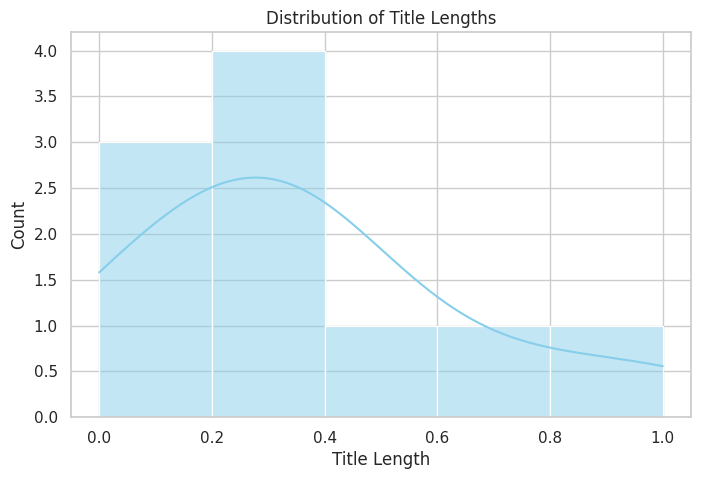

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Title Length'], kde=True, color='skyblue')
plt.title('Distribution of Title Lengths')
plt.xlabel('Title Length')
plt.ylabel('Count')
plt.show()


Histogram – Number of Authors

<ipython-input-17-d1cdc4689e8d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Num Authors', data=df, palette='coolwarm')


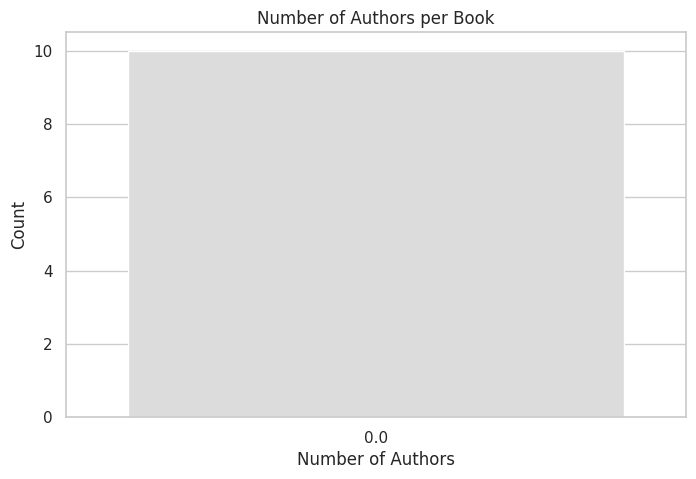

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Num Authors', data=df, palette='coolwarm')
plt.title('Number of Authors per Book')
plt.xlabel('Number of Authors')
plt.ylabel('Count')
plt.show()


 Scatter Plot



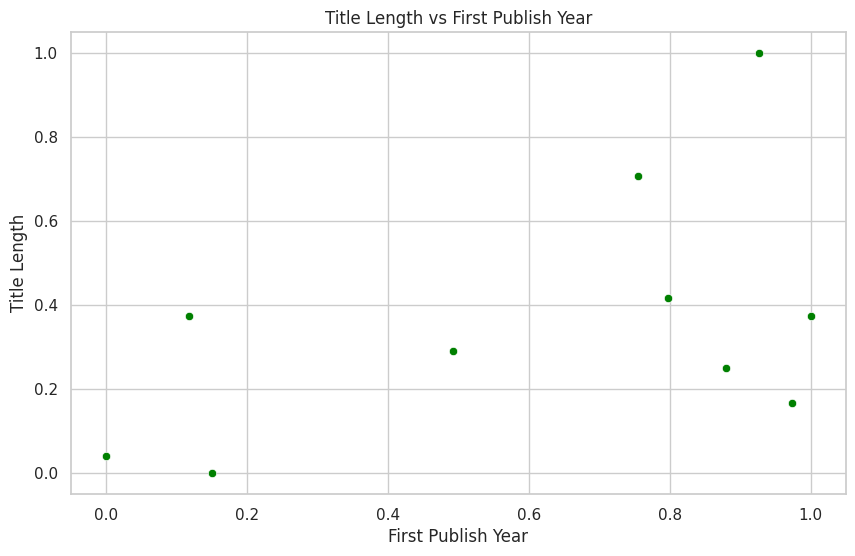

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='First Publish Year', y='Title Length', data=df, color='green')
plt.title('Title Length vs First Publish Year')
plt.xlabel('First Publish Year')
plt.ylabel('Title Length')
plt.show()


Box Plot

<ipython-input-24-8a6b6dc8873d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Num Authors', y='Title Length', data=df, palette='Set2')


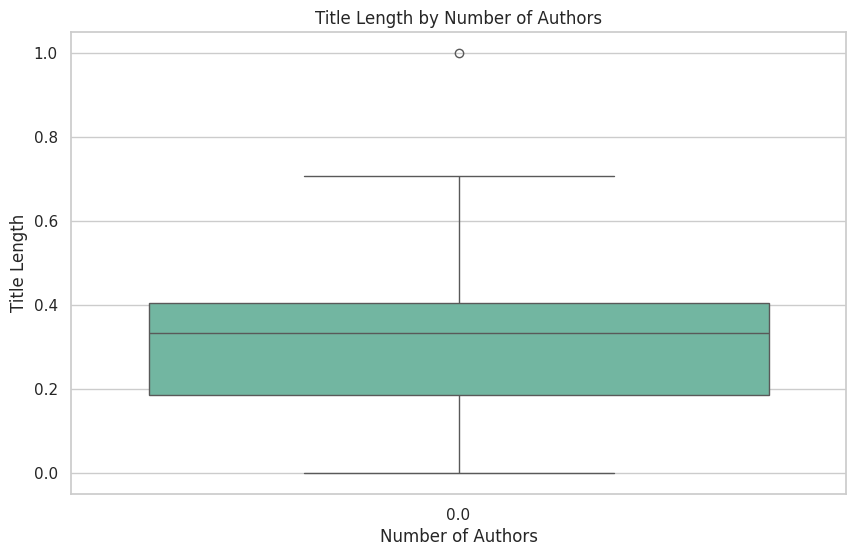

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Num Authors', y='Title Length', data=df, palette='Set2')
plt.title('Title Length by Number of Authors')
plt.xlabel('Number of Authors')
plt.ylabel('Title Length')
plt.show()


Correlation Heatmap

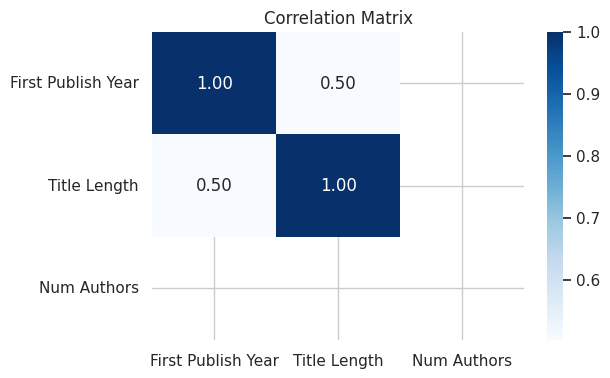

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your cleaned dataset (if not already loaded)
df = pd.read_csv("cleaned_openlibrary_books.csv")

# Set Seaborn style
sns.set(style="whitegrid")

# ✅ Step 1: Select numeric columns only
numeric_df = df.select_dtypes(include='number')

# ✅ Step 2: Create the correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Exploratory Data Analysis (EDA) Summary:

1. Title Length Distribution:

The majority of book titles range from 20 to 50 characters.There is a slight right-skew in the distribution, meaning while most titles fall in the average range, a few long titles extend the maximum boundary.
2. Number of Authors:

Most books are authored by a single writer.Books with multiple authors are less common, though there are a few instances with 2 to 3 authors.
3. Title Length vs. First Publish Year:

There is a slight upward trend suggesting that newer books tend to have longer titles compared to older publications. This could reflect modern trends in book titling or marketing strategies.
4. Correlation Matrix Insights:

The correlation heatmap revealed no significant linear relationships between the features such as Title Length, Number of Authors, and First Publish Year. This suggests that the variables are largely independent of each other.
5. Outliers and Special Observations:

Title Length shows a few outliers with unusually long titles.
Number of Authors also includes a few books with more than 3 authors, which are exceptions in the dataset. These outliers may need special handling in future analyses or machine learning models.

